In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import glob 
import os
print(os.getcwd())

/home/zoujoey/LSY_Projects/safe_control_gym/safe-control-gym/examples/rl


In [2]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w) / w, mode='valid')
    
def load_from_log_file(path):
    '''Return x, y sequence data from the stat csv.'''
    with open(path, 'r') as f:
        lines = f.readlines()
    # Labels.
    xk, yk = [k.strip() for k in lines[0].strip().split(',')]
    # Values.
    x, y = [], []
    for line in lines[1:]:
        data = line.strip().split(',')
        x.append(float(data[0].strip()))
        y.append(float(data[1].strip()))
    x = np.array(x)
    y = np.array(y)
    return xk, x, yk, y

In [4]:
plot_colors = {
    'GP-MPC': 'royalblue',
    'PPO': 'darkorange',
    'SAC': 'red',
    'DPPO': 'pink',
    'iLQR': 'darkgray',
    'Linear MPC': 'green',
    'Nonlinear MPC': 'cadetblue',
    "iLQR": "tab:gray",
    'MAX': 'none',
    'MIN': 'none',
}

legends = {
    "ref": "black",
    "PPO": "PPO",
    "PPO3": "PPO with ilqr ref",
    "PPO4": "PPO with ilqr state ref",
    "SAC": "SAC",
    "TD3": "TD3",
    "DPPO": "DPPO",
    "GP-MPC": "GP-MPC",
    "PPO-MPC": "PPO-MPC"
}

In [ ]:
#data_dir = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/prefinal"

#data_dir = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/prefinal_ilqr_ref"
data_dir1 = "/home/savvyfox/Misc/Olaf/Projects/scg-exp/examples/rl/Results/final"
data_dir2 = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/final_3"
data_dir3 = "/home/savvyfox/Misc/lsy_workstation_08/Projects/scg-exp/examples/rl/Results/final"
data_dir4 = "/home/zoujoey/LSY_Projects/safe_control_gym/safe-control-gym/examples/rl/Results/test"
exp_name = "nominal"
data_paths = {
    # "PPO": data_dir4 + "/" + exp_name + "/quadrotor_2D_attitude_ppo_data",
    # "SAC": data_dir4 + "/" + exp_name + "/quadrotor_2D_attitude_sac_data",
    # "DPPO": data_dir4 + "/" + exp_name + "/quadrotor_2D_attitude_dppo_data",
    "PPO": data_dir4 + "/quadrotor_2D_attitude_ppo_data",
    # "SAC": data_dir4 + "/quadrotor_2D_attitude_sac_data",
    # "DPPO": data_dir4 + "/quadrotor_2D_attitude_dppo_data",
}

### Convergence plot

In [17]:
perf_data = {}
for method in data_paths.keys():
    print(method)
    perf_data.update({method: {}})
    temp = [x for x in os.listdir(data_paths[method])]
    for sd in os.listdir(data_paths[method]):
        seed = sd[4]
        xk, x, lk, l = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_length.log")
        xk, x, yk, y = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_return.log")
        xk, x, zk, z = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_return_std.log")
        # xk, x, ck, c = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/constraint_violation.log")
        xk, x, yk, m = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/rmse.log")
        xk, x, yk, n = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/rmse_std.log")
        # perf_data[method].update({"x": x, "y": y, "z": z, "x1": x1, "y1": y1, "z1": z1})
        perf_data[method].update({int(seed): {"data": x, "ep_return": y, "ep_return_std": z, "rmse": m, "rmse_std": n, "ep_length": l}})

PPO


In [18]:
gp_name = exp_name + '/gpmpc_acados_TP_convergence_results.npy'
gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
gp_mpc_data['rmse'][:,-1].mean()

FileNotFoundError: [Errno 2] No such file or directory: './Data/nominal/gpmpc_acados_TP_convergence_results.npy'

PPO
[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan 0.54123163
 0.37150276 0.22404205 0.15519432 0.14283023 0.10860072 0.1095085
 0.09450513 0.07931266 0.10908801 0.10340713 0.07589117 0.07092257
 0.0636726  0.08718199 0.08009365 0.05474324 0.06435125 0.07256811
 0.05859977 0.05677885 0.05223854 0.05425258 0.0418863  0.04458708
 0.04210246 0.0344139  0.04112097 0.03861219 0.04750753 0.0369746
 0.03892452 0.03645941 0.05072044 0.03802955 0.02919234 0.04400202
 0.03777069 0.04145407]
[ 13200.  26400.  39600.  52800.  66000.  79200.  92400. 105600. 118800.
 132000. 145200. 158400. 171600. 184800. 198000. 211200. 224400. 237600.
 250800. 264000. 277200. 290400. 303600. 316800. 330000. 343200. 356400.
 369600. 382800. 396000. 409200. 422400. 435600. 448800. 462000. 475200.
 488400. 501600. 514800. 528000. 541200. 554400. 567600. 580800. 594000.
 607200. 620400. 633600. 646800. 660000.]
SAC
[       nan        nan     

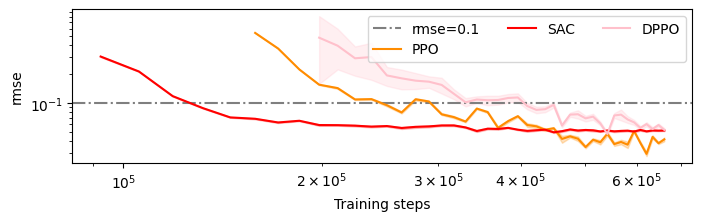

In [6]:
eval_data = {}
mean_fn = np.percentile
perc = 80
n_seeds = 10
seeds = [i for i in range(0, n_seeds)]

fig = plt.figure(figsize=(8, 2)) 
plt.axhline(xmin=0.0, xmax=1.95, y=0.1, linestyle='-.', color=plot_colors["iLQR"], label='rmse=0.1')

#plt.plot(gp_mpc_data['train_steps'], mean_fn(gp_mpc_data['rmse'], perc, axis=0), color=plot_colors["GP-MPC"], label='GP-MPC')
#plt.fill_between(gp_mpc_data['train_steps'], 
#                 np.clip(mean_fn(gp_mpc_data['rmse'], perc, axis=0)-gp_mpc_data['rmse'].std(axis=0), 0, 10), 
#                 np.clip(mean_fn(gp_mpc_data['rmse'], perc, axis=0)+gp_mpc_data['rmse'].std(axis=0), 0, 10), 
#                 color=plot_colors["GP-MPC"], alpha=0.25)

for t, method in enumerate(data_paths.keys()):
    print(method)
    temp = np.zeros((n_seeds, 6, perf_data[method][seeds[0]]["data"].shape[0]))
    for seed in seeds:
        temp[seed, 0, :] = perf_data[method][seed]["data"]
        temp[seed, 1, :] = perf_data[method][seed]["ep_return"]
        temp[seed, 2, :] = perf_data[method][seed]["ep_return_std"]
        temp[seed, 3, :] = perf_data[method][seed]["rmse"]
        temp[seed, 4, :] = perf_data[method][seed]["rmse_std"]
        temp[seed, 5, :] = perf_data[method][seed]["ep_length"]
    j_max = 0
    for seed in seeds:
        for j,k in enumerate(temp[seed, 0, :]):
            if temp[seed, 5, j] < 540:
                temp[seed, 1, j] = np.nan
                temp[seed, 2, j] = np.nan
                temp[seed, 3, j] = np.nan
                temp[seed, 4, j] = np.nan
                if j >= j_max:
                    j_max = j+1
    eval_data.update({method: temp})
    print(mean_fn(temp[:,3,:], perc, axis=0))
    print(temp[0,0,:])

    plt.plot(temp[0,0,:], mean_fn(temp[:,3,:], perc, axis=0), color=plot_colors[method], label=legends[method])
    plt.fill_between(temp[0,0,:], 
                     np.clip(mean_fn(temp[:,3,:]-temp[:,4,:], perc, axis=0), 0, 10),  
                     np.clip(mean_fn(temp[:,3,:]+temp[:,4,:], perc, axis=0), 0, 10), color=plot_colors[method], alpha=0.25)

plt.legend(ncol=3)
# plt.xlim(-10000, 460000)
# plt.xlim(1, 800000)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training steps")
plt.ylabel("rmse")
# plt.title("Task: Quadrotor 2D")
plt.savefig("performance_logx.pdf",bbox_inches="tight", pad_inches=0.1)

### Performance metric

In [10]:
perf_metric = {}
for method in data_paths.keys():
    print(method)
    perf_metric.update({method: {'rmse': [], 'rmse_std': [], 'success': []}})
    for seed in seeds:
        path = data_paths[method] + "/seed"+ str(seed) +"_*/perf_metric.npy"
        file_path = glob.glob(path)
        temp = np.load(file_path[0], allow_pickle=True).item()
        perf_metric[method]['rmse'].append(temp['rmse'])
        perf_metric[method]['rmse_std'].append(temp['rmse_std'])
        temp2 = True if temp['average_length'] == 660.0 else False
        perf_metric[method]['success'].append(temp2)
print(f"Performance of PPO is {np.array(perf_metric['PPO']['rmse']).mean()} +/- {np.array(perf_metric['PPO']['rmse']).std()}")
print(f"Performance of SAC is {np.array(perf_metric['SAC']['rmse']).mean()} +/- {np.array(perf_metric['SAC']['rmse']).std()}")
print(f"Performance of DPPO is {np.array(perf_metric['DPPO']['rmse']).mean()} +/- {np.array(perf_metric['DPPO']['rmse']).std()}")

PPO
SAC
DPPO
Performance of PPO is 0.021713922645520235 +/- 0.004051567655283606
Performance of SAC is 0.044212310969575744 +/- 0.0018721093058055944
Performance of DPPO is 0.030838167648594067 +/- 0.007360741672173907


### Generalization metric

In [66]:
transfer_metric = {}
for method in data_paths.keys():
    print(method)
    transfer_metric.update({method: {'rmse': [], 'rmse_std': [], 'success': []}})
    for seed in seeds:
        path = data_paths[method] + "/seed"+ str(seed) +"_*/transfer_metric_11.npy"
        file_path = glob.glob(path)
        # print(data_paths[method])
        # print(file_path)
        temp = np.load(file_path[0], allow_pickle=True).item()
        transfer_metric[method]['rmse'].append(temp['rmse'])
        transfer_metric[method]['rmse_std'].append(temp['rmse_std'])
        temp2 = True if temp['average_length'] == 660.0 else False
        transfer_metric[method]['success'].append(temp2)
print(f"Performance of PPO is {np.array(transfer_metric['PPO']['rmse']).mean()} +/- {np.array(transfer_metric['PPO']['rmse']).std()}")
print(f"Performance of SAC is {np.array(transfer_metric['SAC']['rmse']).mean()} +/- {np.array(transfer_metric['SAC']['rmse']).std()}")
print(f"Performance of DPPO is {np.array(transfer_metric['DPPO']['rmse']).mean()} +/- {np.array(transfer_metric['DPPO']['rmse']).std()}")

PPO
SAC
DPPO
Performance of PPO is 0.021604097983791027 +/- 0.004167241640488291
Performance of SAC is 0.04410137020535634 +/- 0.0018198729054740466
Performance of DPPO is 0.03087288620530012 +/- 0.00768146025248008


In [67]:
episode_len_list = [9, 10, 11, 12, 13, 14, 15]
episode_len_list2 = [4.5, 5, 5.5, 6, 6.5, 7, 7.5]
transfer_metric = {}
for method in data_paths.keys():
    print(method)
    transfer_metric.update({method: {'rmse': [], 'rmse_std': []}})
    for T in episode_len_list:
        rmse, rmse_std = [], []
        for seed in seeds:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/transfer_metric_"+str(T)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            rmse.append(temp['rmse'])
            rmse_std.append(temp['rmse_std'])
        transfer_metric[method]['rmse'].append(np.array(rmse).mean())
        transfer_metric[method]['rmse_std'].append(np.array(rmse_std).mean())
    transfer_metric[method]['rmse'] = np.array(transfer_metric[method]['rmse'])
    transfer_metric[method]['rmse_std'] = np.array(transfer_metric[method]['rmse_std'])

PPO
SAC
DPPO


In [36]:
# gp_name = exp_name + '/gpmpc_acados_TP_tr_gen_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data)
# dummy_list = ['_9', '_10', '_11', '_12', '_13', '_14', '_15']
# gpmpc_gen = {'rmse': [], 'rmse_std': []}
# for i in dummy_list:
#     gpmpc_gen['rmse'].append(gp_mpc_data[i]['mean_rmse'])
#     gpmpc_gen['rmse_std'].append(gp_mpc_data[i]['std_rmse'])

PPO
DPPO
SAC


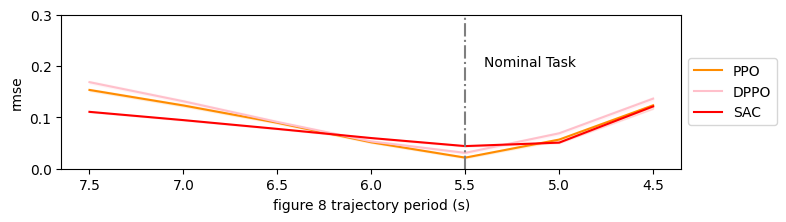

In [68]:
fig = plt.figure(figsize=(8, 2))
plot_list = [
    'PPO', 'DPPO', 'SAC'
]
for method in plot_list:
    print(method)
    plt.plot(episode_len_list2, transfer_metric[method]['rmse'], label=method, color=plot_colors[method])
    plt.fill_between(episode_len_list2, 
                     transfer_metric[method]['rmse']-transfer_metric[method]['rmse_std'],  
                     transfer_metric[method]['rmse']+transfer_metric[method]['rmse_std'], color=plot_colors[method], alpha=0.1)

# plt.plot(episode_len_list2, gpmpc_gen['rmse'], label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(episode_len_list2, 
#                  np.array(gpmpc_gen['rmse'])-np.array(gpmpc_gen['rmse_std']),  
#                  np.array(gpmpc_gen['rmse'])+np.array(gpmpc_gen['rmse_std']), color=plot_colors['GP-MPC'], alpha=0.1)

plt.axvline(x=5.5, linestyle='-.', color=plot_colors['iLQR'])
#plt.axvline(x=7.5, linestyle='-.', color=plot_colors['iLQR'])
#plt.axvline(x=4.5, linestyle='-.', color=plot_colors['iLQR'])
plt.text(5.4, 0.2, 'Nominal Task')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(0,0.3)
#plt.xlim(0,50)
plt.gca().invert_xaxis()
plt.xlabel("figure 8 trajectory period (s)")
plt.ylabel("rmse")
plt.savefig("generalization_curve.pdf",bbox_inches="tight", pad_inches=0.1)

In [26]:
transfer_metric

{'PPO': {'rmse': array([0.1233724 , 0.05674868, 0.0216041 , 0.05145831, 0.08954208,
         0.12323273, 0.15347746]),
  'rmse_std': array([0.00283469, 0.00217857, 0.00157792, 0.00169978, 0.00184708,
         0.00228554, 0.00219444])},
 'SAC': {'rmse': array([0.12137596, 0.05084581, 0.04410137, 0.05974511, 0.07759334,
         0.09469564, 0.11081217]),
  'rmse_std': array([0.00473113, 0.00094658, 0.00095094, 0.00072694, 0.00069054,
         0.00080861, 0.00071439])},
 'DPPO': {'rmse': array([0.13649782, 0.06901244, 0.03087289, 0.05318802, 0.09108603,
         0.13137159, 0.16864583]),
  'rmse_std': array([0.00337218, 0.00265538, 0.00196296, 0.00224129, 0.00283238,
         0.00293171, 0.00283812])}}

### Robustness metric: Observation noise

In [7]:
metric = {}
noise_scale = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
for method in data_paths.keys():
    print(method)
    metric.update({method: {}})
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_ob_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            if ns in metric[method].keys():
                metric[method][ns]['rmse'].append(temp['rmse'])
                metric[method][ns]['rmse_std'].append(temp['rmse_std'])
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method][ns]['success'].append(temp2)
            else:
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method].update({ns: {'rmse': [temp['rmse']], 
                                            'rmse_std': [temp['rmse_std']], 
                                            'success': [temp2]}})

PPO
SAC
DPPO


PPO
[0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
50
[ 100.           99.04987806   98.84953757   98.01656925   98.70693323
   98.133971    107.53384871  145.67865567  219.56342359  306.54690103
  423.04644636  662.08465833  916.34565532 1189.91938272 1454.23525049
 1711.12217764 1980.89648297 2221.77963352]
SAC
[0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
50
[100.          99.77524907 100.31947135 100.01976976 100.01195751
 100.27839195 100.12341155 100.28667944 100.23511127 100.51032304
 101.0938112  100.93376444 103.89034944 106.86972655 109.96632629
 113.15098094 119.94115934 124.82968965]
DPPO
[0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
50
[ 100.           99.89503182   99.80964544  103.16833316  106.74412982
  110.92174676  142.04500036  189.87998162  260.00093696  346.91529472
  440.15728732  652.1092983   918.62864633 1197.54110732 1487.83404757
 1819.43088279 2079.34115487 2254.04863953]


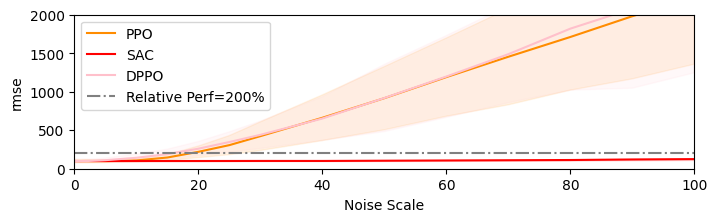

In [8]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 50
    count = 50
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    print(noise_scale)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    print(temp*100/temp[0])
    ddd = 100/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

# ddd = 100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative Perf=200%')
# plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(16, 500, 'PPO \nearly stop')
#plt.text(31, 500, 'SAC \nearly stop')
#plt.text(16, 2500, 'DPPO \nearly stop')


plt.legend()
plt.ylim(0,2000)
# plt.ylim(0,1.0)
plt.xlim(0,100)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
# plt.ylabel("Relative Performance %")
plt.ylabel("rmse")
#plt.title("TD3 for Quadrotor 2D")
plt.savefig("robustness_ob_rl.pdf",bbox_inches="tight", pad_inches=0.1)

## Robustness metric: Process Noise

In [9]:
metric = {}
noise_scale = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50]
for method in data_paths.keys():
    print(method)
    metric.update({method: {}})
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_ps_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            if ns in metric[method].keys():
                metric[method][ns]['rmse'].append(temp['rmse'])
                metric[method][ns]['rmse_std'].append(temp['rmse_std'])
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method][ns]['success'].append(temp2)
            else:
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method].update({ns: {'rmse': [temp['rmse']], 
                                            'rmse_std': [temp['rmse_std']], 
                                            'success': [temp2]}})

PPO
SAC
DPPO


In [82]:
# gp_name =  'ps5/gpmpc_acados_TP_proc_ns=5_proc_noise_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data['rmse_mean'][:13])
# print(gp_mpc_data.keys())

PPO
15
[0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50]
[ 100.          102.58442076  119.12644134  147.5977621   189.61121558
  256.38686295  802.73562981 1605.68825972 2386.30504669 3200.25177037
 3629.6780788  3967.11756524 4143.8062214 ]
SAC
10
[0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50]
[ 100.          100.59963267   99.96569375  100.49420213  106.43934181
  138.74311286  955.26883087 1237.38465441 1442.08710194 1563.7594679
 1777.52235789 1710.97313749 1666.37365923]
DPPO
10
[0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50]
[ 100.          105.16823471  123.22924164  159.30192691  213.24517764
  275.10244718  959.52750406 1814.79678632 2318.66270873 2591.96137199
 2812.64468723 2794.67238054 2595.09189106]


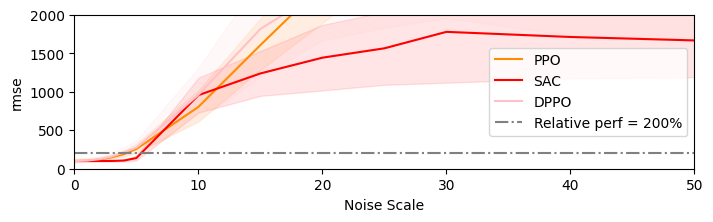

In [10]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 200
    count = 0
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - 1*data.std())
        temp_std2.append(data.mean() + 1*data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    print(noise_scale)
    print(temp*100/temp[0])
    ddd = 100/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)
ddd= 1#100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative perf = 200%')
# plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(41, 2000, 'PPO \nearly stop')
#plt.text(6, 1500, 'SAC \nearly stop')
#plt.text(31, 1000, 'DPPO \nearly stop')


plt.legend()
plt.ylim(0,2000)
#plt.ylim(0,0.8)
plt.xlim(0,50)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
# plt.ylabel("Relative Performance %")
plt.ylabel("rmse")
#plt.title("TD3 for Quadrotor 2D")
plt.savefig("robustness_ps_rl.pdf",bbox_inches="tight", pad_inches=0.1)

### Robustness metric: Parametric noise

In [12]:
metric = {}
# noise_scale = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
noise_scale = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
for method in data_paths.keys():
    print(method)
    metric.update({method: {}})
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_pm_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            if ns in metric[method].keys():
                metric[method][ns]['rmse'].append(temp['rmse'])
                metric[method][ns]['rmse_std'].append(temp['rmse_std'])
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method][ns]['success'].append(temp2)
            else:
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method].update({ns: {'rmse': [temp['rmse']], 
                                            'rmse_std': [temp['rmse_std']], 
                                            'success': [temp2]}})

PPO
SAC
DPPO


PPO
3.0
[0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
[ 100.          104.96268385  106.71131432  142.20899908  162.62583798
  185.98202656  234.33325371  284.13159129  261.72445594  358.22685711
  415.90900223  542.81606112  867.25526905  875.3393634   677.51529992
 1311.81297763 1430.78641032]
SAC
2.5
[0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
[100.         100.27949435 101.15039961 101.55096816 101.79208533
 107.58371882 106.14411755 112.51950193 131.05684634 109.40142405
 117.04139857 296.01489125 537.54619    511.53634753 591.35161064
 267.2570741  927.07612576]
DPPO
2.0
[0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
[ 100.          108.57065635  118.62915456  134.43268686  187.11273782
  192.87900383  186.23566498  211.29917545  225.21591026  274.04461944
  303.95438419  479.4703059   477.75735699  654.35874234 1118.03428586
  732.30500165 1251.68748575]


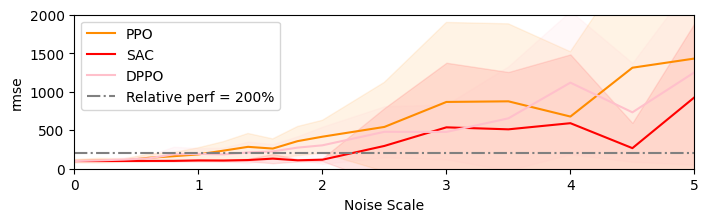

In [13]:
fig = plt.figure(figsize=(8, 2))
for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 200
    count = 0
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - 1*data.std())
        temp_std2.append(data.mean() + 1*data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)
    print(noise_scale)
    print(temp*100/temp[0])
    
    
    #plt.plot(noise_scale[:count+1], temp[:count+1]*100/temp[0], color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(noise_scale[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    ddd = 100/temp[0]
    plt.plot(noise_scale, temp*ddd, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)
ddd= 1#100/gp_mpc_data['rmse_mean'][0]
# plt.plot(noise_scale, gp_mpc_data['rmse_mean'][:13]*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(noise_scale, 
#                  (gp_mpc_data['rmse_mean'][:13]-gp_mpc_data['rmse_std'][:13])*ddd,  
#                  (gp_mpc_data['rmse_mean'][:13]+gp_mpc_data['rmse_std'][:13])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)

plt.plot(noise_scale, [200]*len(noise_scale), color='grey', linestyle='-.', label='Relative perf = 200%')
# plt.plot(noise_scale, [0.1]*len(noise_scale), color='grey', linestyle='-.', label='rmse=0.1')

#plt.text(41, 2000, 'PPO \nearly stop')
#plt.text(6, 1500, 'SAC \nearly stop')
#plt.text(31, 1000, 'DPPO \nearly stop')


plt.legend()
#plt.ylim(0,2)
plt.ylim(0,2000)
plt.xlim(0,5)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Noise Scale")
# plt.ylabel("Relative Performance %")
plt.ylabel("rmse")
# plt.title("TD3 for Quadrotor 2D")
plt.savefig("robustness_pm_rl.pdf",bbox_inches="tight", pad_inches=0.1)

### Robustness Metric: Downwash

In [76]:
metric = {}
downwash_height = [1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5, 4.0, 4.5]
for method in data_paths.keys():
    print(method)
    metric.update({method: {}})
    for seed in seeds:
        for ns in downwash_height:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_dw_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            if ns in metric[method].keys():
                metric[method][ns]['rmse'].append(temp['rmse'])
                metric[method][ns]['rmse_std'].append(temp['rmse_std'])
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method][ns]['success'].append(temp2)
            else:
                temp2 = True if temp['average_length'] >= 660.0 else False
                metric[method].update({ns: {'rmse': [temp['rmse']], 
                                            'rmse_std': [temp['rmse_std']], 
                                            'success': [temp2]}})

PPO
SAC
DPPO


In [77]:
# gp_name = 'nominal/gpmpc_acados_TP_downwash_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data['rmse_mean'][:13])
# print(gp_mpc_data.keys())
# print(gp_mpc_data['dw_height'])

PPO
50
SAC
1.5
DPPO
50


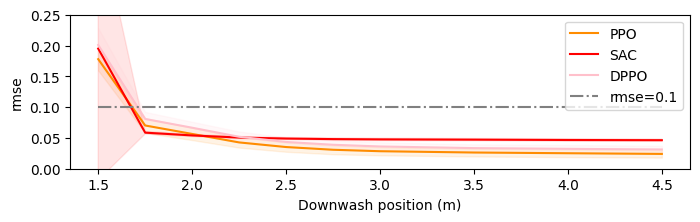

In [78]:
fig = plt.figure(figsize=(8, 2))

for method in metric.keys():
    print(method)
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 50
    count = 50
    for k, ns in enumerate(downwash_height):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        # print(all(metric[method][ns]['success']))
        if not all(metric[method][ns]['success']) and traj_success_till > ns:
            traj_success_till = ns
            count = k
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(traj_success_till)

    ddd = 1 #100/temp[-1]
    plt.plot(downwash_height, temp*ddd, color=plot_colors[method], label=method)
    #plt.axvline(x=traj_success_till, linestyle='-.', linewidth=0.5, color=plot_colors[method])
    #plt.plot(downwash_height[count:], temp[count:]*100/temp[0], color=plot_colors[method], linestyle='--')
    plt.fill_between(downwash_height, 
                     temp_std1*ddd,  
                     temp_std2*ddd, color=plot_colors[method], alpha=0.1)
    
    #plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

# ddd = 100/gp_mpc_data['rmse_mean'][-1]
# plt.plot(gp_mpc_data['dw_height'], gp_mpc_data['rmse_mean']*ddd, label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(gp_mpc_data['dw_height'], 
#                  (gp_mpc_data['rmse_mean']-gp_mpc_data['rmse_std'])*ddd,  
#                  (gp_mpc_data['rmse_mean']+gp_mpc_data['rmse_std'])*ddd, 
#                  color=plot_colors['GP-MPC'], alpha=0.1)
plt.plot(downwash_height, [0.1]*len(downwash_height), color='grey', linestyle='-.', label='rmse=0.1')
#plt.text(16, 100, 'PPO \nearly stop')
#plt.text(31, 500, 'SAC \nearly stop')
#plt.text(11, 100, 'DPPO \nearly stop')


plt.legend()
#plt.ylim(0,1000)
plt.ylim(0,0.25)
#plt.xlim(0,50)
# plt.xscale("log")
# plt.gca().invert_xaxis()
# plt.yscale("log")
plt.xlabel("Downwash position (m)")
plt.ylabel("rmse")
#plt.title("TD3 for Quadrotor 2D")
plt.savefig("robustness_dw_rl.pdf",bbox_inches="tight", pad_inches=0.1)

### Rough plots for individual seeds

In [16]:
colors = {
    "ref": "black",
    "PPO": "orange",
    "PPO2": "red",
    "PPO3": "tab:cyan",
    "PPO4": "royalblue",
    "DPPO": "darkorange",
    "DPPO2": "red",
    "DPPO3": "tab:cyan",
    "DPPO4": "royalblue",
    "SAC": "royalblue",
    "iLQR": "tab:gray",
}
legends = {
    "PPO": "PPO",
    "PPO2": "2",
    "PPO3": "3",
    "PPO4": "4",
    "DPPO": "DPPO",
    "DPPO2": "2",
    "DPPO3": "3",
    "DPPO4": "4",
    "SAC": "SAC"
}
seeds = [i for i in range(0,5)]

In [18]:
data_paths = {
    "PPO": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data/",
    #"PPO2": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data2/",
    #"PPO3": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data3/",
    #"PPO4": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data4/",
    #"DPPO": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data/",
    #"DPPO2": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data2/",
    #"DPPO3": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data3/",
    #"DPPO4": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data4/",
    
    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Test_runs/quadrotor_2D_attitude_ppo_data/',

    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_ppo_data/',
    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_ppo_data2/',
    #'DPPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_dppo_data2/',
    #'SAC': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_sac_data2/',
    
    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data/',
    #'PPO2': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data2/',
    #'PPO3': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data3/',
    #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data2/',
    #'DPPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data/',
    #'DPPO2': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data2/',
    #'DPPO3': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data3/',
    
}

perf_data = {}
for method in data_paths.keys():
    print(method)
    perf_data.update({method: {}})
    for seed in seeds:
        # print(data_paths[method] + str(seed) + "/logs/stat_eval/ep_length.log")
        xk, x, lk, l = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_length.log")
        xk, x, yk, y = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_return.log")
        xk, x, zk, z = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_return_std.log")
        # xk, x, ck, c = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/constraint_violation.log")
        # perf_data[method].update({seed: {"x": x, "y": y, "c": c}})
        # perf_data[method].update({seed: {"x": x, "y": y, "z": z, "c": c}})
        xk, x, yk, m = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/rmse.log")
        xk, x, yk, n = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/rmse_std.log")
        # perf_data[method].update({"x": x, "y": y, "z": z, "x1": x1, "y1": y1, "z1": z1})
        perf_data[method].update({seed: {"x": x, "y": y, "z": z, "m": m, "n": n, "l": l}})

PPO


In [144]:
eval_data = {}
w = 1
fig = plt.figure(figsize=(8, 3))
mean_fn = np.percentile
perc = 90
plot_seeds = True

for t, method in enumerate(data_paths.keys()):
    print(method)
    temp = np.zeros((len(seeds), 6, perf_data[method][seeds[0]]["x"].shape[0]))
    for seed in seeds:
        temp[seed, 0, :] = perf_data[method][seed]["x"]
        temp[seed, 1, :] = perf_data[method][seed]["y"]
        temp[seed, 2, :] = perf_data[method][seed]["z"]
        temp[seed, 3, :] = perf_data[method][seed]["m"]
        temp[seed, 4, :] = perf_data[method][seed]["n"]
        temp[seed, 5, :] = perf_data[method][seed]["l"]
    j_max = 0
    for seed in seeds:
        for j,k in enumerate(temp[seed, 0, :]):
            if temp[seed, 5, j] < 660:
                temp[seed, 1, j] = np.nan
                temp[seed, 2, j] = np.nan
                temp[seed, 3, j] = np.nan
                temp[seed, 4, j] = np.nan
    eval_data.update({method: temp})

    # plot
    plt.plot(temp[0,0,:], mean_fn(temp[:,3,:], perc, axis=0), color=colors[method], label=legends[method])
    plt.fill_between(temp[0,0,:], 
                     np.clip(mean_fn(temp[:,3,:]+w*temp[:,4,:], perc, axis=0), 0, 10),  
                     np.clip(mean_fn(temp[:,3,:]-w*temp[:,4,:], perc, axis=0), 0, 10), color=colors[method], alpha=0.2)
    if plot_seeds:
        for seed in seeds:
            plt.plot(temp[seed,0,:], temp[seed,3,:], label=seed)
            plt.fill_between(temp[0,0,:], 
                             np.clip(temp[seed,3,:]-w*temp[seed,4,:], 0, 10),  
                             np.clip(temp[seed,3,:]+w*temp[seed,4,:], 0, 10), alpha=0.)



# s = 1 # time std
# rmse_ilqr_mean = 0.026000000000000002 * 0
# rmse_ilqr_std = 0.001843908891458577 * 0
plt.axhline(xmin=0.0, xmax=1.95, y=0.1, linestyle='-.', color=colors["iLQR"], label='rmse=0.1')
# plt.fill_between([0.0, last_iter], rmse_ilqr_mean-s*rmse_ilqr_std, rmse_ilqr_mean+s*rmse_ilqr_std, color=colors["iLQR"], alpha=0.25)

# real experiment data
# plt.plot(last_iter, 0.086, color=colors['PPO'], marker='x')
# plt.plot(last_iter, 0.064, color=colors['SAC'], marker='x')

plt.legend(ncol=3)
# plt.ylim(-200,00)
# plt.xlim(right=6e5)
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training steps")
plt.ylabel("RMSE")
#plt.title("Task: Quadrotor 2D")
#plt.savefig("performance_logx.pdf",bbox_inches="tight", pad_inches=0.0)

PPO


KeyError: 'x'

<Figure size 800x300 with 0 Axes>

In [7]:
mean_fn = np.mean
for method in eval_data.keys():
    print(method)
    print(mean_fn(eval_data[method][:, 3, :], axis=0))

PPO
[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan 0.26790361 0.22807108 0.18980713 0.16330053 0.13762581
 0.1207609  0.10932789 0.0900497  0.07063229 0.0585894  0.0466095
 0.0460997  0.04961646 0.04840762 0.04278864 0.03734574 0.03677834
 0.03701848 0.03908621 0.03867297 0.0360975  0.03486813 0.04169359
 0.03725969 0.03457009 0.03849986 0.03885277 0.0400471  0.04342527
 0.041256   0.0388206  0.03144821 0.03468308 0.03563006 0.03330509
 0.03826558 0.07731813]
DPPO
[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan 0.25586162 0.24190134 0.22537191 0.20194781 0.18302899
 0.17394095 0.15722846 0.13726